### __Fitting a multiple linear regression model in sklearn__

Simple linear regression can only hold one predictor at a time. Multiple linear regression (MLR) lets you bring all of them in together.

You have already built a simple regression model: one predictor, one outcome. But most real prediction problems do not work that way. House prices depend on size, location, and age. Exam scores depend on study hours, prior grades, and sleep. In this video, you will see how multiple linear regression handles many predictors at once, and how to check that the model you have built is actually trustworthy.

When you predicted a car's fuel efficiency from its weight alone, you left a lot on the table. Engine size, number of cylinders, and horsepower all affect how far a tank of fuel takes you, and a model with one predictor cannot account for any of that. Multiple linear regression lets you include several predictors at once and tease apart each one's contribution. In this example, you will fit a multiple linear regression model in sklearn using the mtcars dataset, working through the end-to-end workflow from data preparation to extracting fitted coefficients.



Recall that the simple linear regression equation is as follows:

$$Y = \beta_{0} + \beta_{1}X_1$$

where:
- $\beta_{0}$ is the intercept, interpreted as the value of $Y$ when $X_1 = 0$.
- $\beta_{1}$ is the coefficient, interpreted as the effect on $Y$ for a one-unit increase in $X_1$.
- $X_1$ is the single predictor variable.

Extending that idea to multiple linear regression is as simple as adding an **$X_{j}$** and corresponding **$\beta_{j}$** for each of the **$p$** predictor variables, where **$j$** is an element of the set **$[1,p]$**.

Hence in multiple linear regression, our regression equation becomes:

**$$Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_pX_p$$**

where:

- **$Y$** is the response variable which depends on the **$p$ predictor variables**.
- **$\beta_0$** is the intercept, interpreted as the value of **$Y$** when _all_ predictor variables are equal to zero.
- **$\beta_j$** is the average effect on **$Y$** of a one-unit increase in **$X_j$**, assuming all other predictors are held fixed.
  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [2]:
from styleplot import style_plot

### __The Dataset__
Next we will load our data as a Pandas DataFrame. For this notebook, we'll be using the famous `mtcars` dataset, an extract from the 1974 US Motor Trend magazine, which comprises fuel consumption and 10 aspects of automobile design and performance for 32 automobiles.

In [3]:
#read the dataset
#df = pd.read_csv("https://cdn.alx-ai-tools.com/marimo/v2/data/Data/regression_sprint/mtcars.csv", index_col=0)

In [4]:
#df.to_csv("mtcars.csv", index = False)

In [5]:
cars = pd.read_csv("mtcars.csv")

In [6]:
cars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [7]:
#Explore the shape of the dataset
cars.shape

(32, 11)

In [8]:
print(cars.info())

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 2.9 KB
None


As we can see, the DataFrame contains multiple columns – 11 in total.

Simple linear regression models make use of a single predictor variable when fitting a model. While that seems easy to understand, the world is seldom as simple as that. Real problems contain multiple variables and we need to take into account as many as necessar

### __Modelling miles per gallon__

Let's attempt to model the miles per gallon (_mpg_) rating of a car using its other characteristics. `mpg` is an intuitive response variable and we would expect it to be negatively impacted by things like a heavier car (_wt_), higher horsepower (_hp_), and bigger engine displacement (_disp_), among other things.

To start with, we'll carry out this multiple linear regression in `sklearn`.

To get a better idea of what a multi-dimensional dataset looks like, we'll generate a 3D scatter plot showing the `mpg` on the _z_-axis, with two predictor variables, `cyl` and `disp` on the _x_- and _y_-axes.

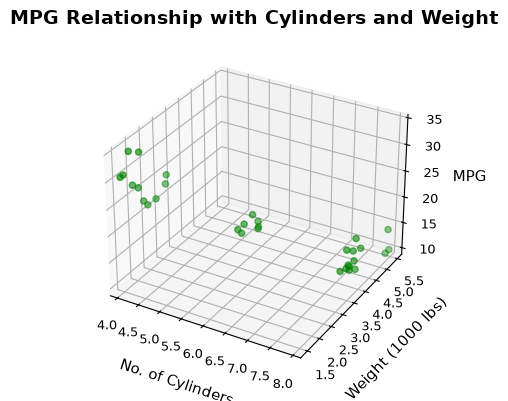

In [24]:
fig = plt.figure(figsize=(6, 4))

ax = fig.add_subplot(111, projection="3d")

# Scatter plot
ax.scatter(
    cars["cyl"],
    cars["wt"],
    cars["mpg"],
    color = '#347989',
    alpha = 0.8
)

# Apply your styling function
style_plot(
    ax,
    title="MPG Relationship with Cylinders and Weight",
    xlabel="No. of Cylinders",
    ylabel="Weight (1000 lbs)",
    zlabel="MPG"
)

plt.tight_layout()
plt.show()

In [16]:
# import regression module
from sklearn.linear_model import LinearRegression
# import train/test split module
from sklearn.model_selection import train_test_split

In [14]:
# split predictors and response
X = cars.drop(['mpg'], axis=1)
y = cars['mpg']

In [15]:
lm = LinearRegression()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [18]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.19, 0.01,-0.02,..., 1.34, 0.48,-0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['cyl','disp','hp',...,'am','gear','carb']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.465
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [19]:
# extract model intercept
beta_0 = float(lm.intercept_)

In [31]:
# extract model coefficients
coef = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])

In [21]:
print("Intercept:", beta_0)

Intercept: 8.465282572242629


In [32]:
coef

,Coefficient
cyl,0.190203
disp,0.008613
hp,-0.022868
drat,1.477014
wt,-3.564785
qsec,0.924358
vs,-1.248904
am,1.340890
gear,0.482458
carb,-0.187354


The results show the coefficients of the features in the model. These coefficients indicate the change in the response variable for a one-unit change in the corresponding feature, holding all other features constant. Positive coefficients indicate a positive relationship with the response variable, while negative coefficients indicate a negative relationship.

__For example:__
> The __wt__ coefficient means that, holding all the other predictors constant, a one-unit increase in weight is associated with about a 3.56 decrease in MPG.

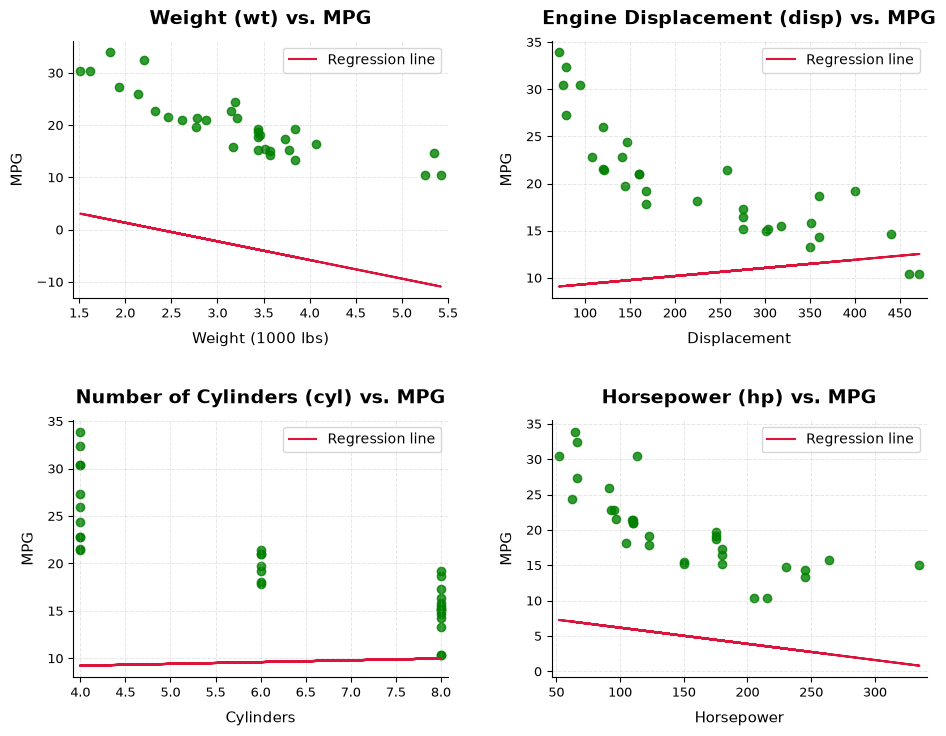

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Flatten the axes
axs = axs.ravel()

plots = [
    ("wt", "Weight (wt) vs. MPG", "Weight (1000 lbs)"),
    ("disp", "Engine Displacement (disp) vs. MPG", "Displacement"),
    ("cyl", "Number of Cylinders (cyl) vs. MPG", "Cylinders"),
    ("hp", "Horsepower (hp) vs. MPG", "Horsepower")
]

for ax, (column, title, xlabel) in zip(axs, plots):

    # Scatter plot
    ax.scatter(
        cars[column],
        cars["mpg"],
        color="green",
        alpha=0.8
    )

    # Regression line using the coefficient DataFrame
    coefficient = coef.loc[column, "Coefficient"]

    ax.plot(
        cars[column],
        lm.intercept_ + coefficient * cars[column],
        color="crimson",
        label="Regression line"
    )

    # Apply your styling
    style_plot(
        ax,
        title=title,
        xlabel=xlabel,
        ylabel="MPG"
    )

    ax.legend()

plt.tight_layout(pad=3.0)
plt.show()

It looks as if some of the predictors have been somewhat correctly modelled by the regression. Others, like `disp` in the top-right, are nowhere near.

### __Accessing Model Accuracy__

Let's assess the fit of our multivariate model. For a rudimentary comparison, let's measure model accuracy against a simple linear regression model that uses only disp as a predictor variable for mpg.

In [26]:
# comparison linear model
slr = LinearRegression()

slr.fit(X_train[['disp']], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['disp']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,27.49
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [27]:
from sklearn import metrics
import math

Let's calculate the training mean squared error (MSE), test MSE, and test the root mean squared error (RMSE) for both our simple linear regression (SLR) and multiple linear regression (MLR) models.

In [28]:
results_dict = {
    "Training MSE": {
        "SLR": metrics.mean_squared_error(
            y_train,
            slr.predict(X_train[["disp"]])
        ),
        "MLR": metrics.mean_squared_error(
            y_train,
            lm.predict(X_train)
        )
    },

    "Test MSE": {
        "SLR": metrics.mean_squared_error(
            y_test,
            slr.predict(X_test[["disp"]])
        ),
        "MLR": metrics.mean_squared_error(
            y_test,
            lm.predict(X_test)
        )
    },

    "Test RMSE": {
        "SLR": math.sqrt(
            metrics.mean_squared_error(
                y_test,
                slr.predict(X_test[["disp"]])
            )
        ),
        "MLR": math.sqrt(
            metrics.mean_squared_error(
                y_test,
                lm.predict(X_test)
            )
        )
    }
}

In [29]:
results_df = pd.DataFrame(results_dict)

results_df

,Training MSE,Test MSE,Test RMSE
SLR,8.201521,20.500165,4.527711
MLR,3.737534,11.520901,3.394245


So this comparison lets you determine whether using multiple car characteristics improves MPG prediction compared with using engine displacement alone.

One useful rule when interpreting the table:

> __Lower MSE and RMSE = better predictive performance.__

In particular, focus on Test MSE and Test RMSE when deciding which model generalizes better to unseen cars.

We have included a column, *test RMSE*, which is simply the square root of the *test MSE*.

\begin{align}
RMSE & = \sqrt{MSE} \\
     & = \sqrt{\frac{1}{N}\sum^{N} (\hat{y_i} - y_i)^{2}}
\end{align}

where $y_i$ are the actual target values for a dataset with $N$ datapoints, and $\hat{y_i}$ represent our corresponding predictions. RMSE is a more intuitive metric to use than MSE because it is in the same units as the underlying variable being predicted.

For instance, MSE would be measured in units of $mpg^2$, whereas RMSE is measured in the same units as $mpg$.

Clearly the multiple linear regression performed a lot better than using just `disp` to try and predict `mpg`, underpinning that the relationship between the dependent variable (mpg) and the independent variables is **not adequately captured by a single predictor**.

 By incorporating multiple predictors simultaneously, the multiple linear regression model can **account for the combined influence of these factors** on the dependent variable, resulting in **improved predictive performance** and a **more accurate representation** of the underlying relationship in the data.